## Preprocessing District GeoJSON

Extracting only the columns that we need.

In [3]:
import geopandas

### Arkansas Congressional District Path

In [4]:
path = '../../data/Arkansas/Arkansas_Congressional_Districts.json'

### GeoJson to geopandas

In [5]:
gdf = geopandas.read_file(path)
gdf

,objectid,district,st_area(sh,st_length(,geometry
0,409,2,1.408334e+10,8.158292e+05,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
1,410,4,5.981706e+10,1.689231e+06,"POLYGON ((517207.32159 3953177.73508, 517207.1..."
2,411,1,5.282824e+10,2.334336e+06,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
3,412,3,1.098867e+10,5.649465e+05,"POLYGON ((473744.18734 4039274.20057, 473495.9..."


In [7]:
gdf.columns

Index(['objectid', 'district', 'st_area(sh', 'st_length(', 'geometry'], dtype='str')

### Validating Geometry

<Axes: >

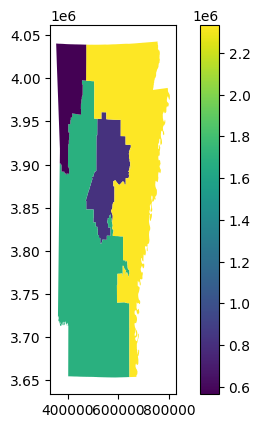

In [11]:
gdf.plot("st_length(", legend=True)

### Drop and Rename Columns

In [13]:
gdf = gdf.drop(columns=['objectid', 'st_area(sh', 'st_length('])
gdf

,district,geometry
0,2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
1,4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."
2,1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
3,3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."


In [14]:
gdf = gdf.sort_values(by='district')
gdf

,district,geometry
2,1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
0,2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
3,3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."
1,4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."


In [16]:
gdf['district'] = gdf['district'].map(lambda p: f'Congressional District {str(p)}')
gdf

,district,geometry
2,Congressional District 1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
0,Congressional District 2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
3,Congressional District 3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."
1,Congressional District 4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."


In [17]:
gdf = gdf.rename(columns={'district' : 'DISTRICT'})
gdf

,DISTRICT,geometry
2,Congressional District 1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
0,Congressional District 2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
3,Congressional District 3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."
1,Congressional District 4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."


### Save to Output

In [18]:
gdf.to_file("../output/Arkansas/Arkansas_Congressional_Districts.geojson", driver="GeoJSON")